# Word Count Analysis Notebook
This notebook builds on the data that exists after running the code in the notebook called 'descriptive stats.ipynb'

### 1. Importing Data
Imports the csv file that was saved at the end of the descriptive_stats notebook. 

NB: If you are using an environment, please remember to choose kernal accordingly

In [1]:
# Import libraries

import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import numpy as np
import nltk
from scipy.stats import levene
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from nltk.tokenize import word_tokenize

# Import CSV file
df_all = pd.read_csv("df_desc_filt.csv", encoding="utf-8")


/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_74029/1522445283.py:15: DtypeWarning: Columns (132,134) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv("df_desc_filt.csv", encoding="utf-8")


### 2. Word Count Analysis

                            count        mean         std   min    25%    50%  \
Group                                                                           
Post-ChatGPT (2024/2025)  10051.0  536.953736  264.634226  20.0  325.5  516.0   
Pre-ChatGPT(2022)         14617.0  463.651707  253.854751  18.0  262.0  436.0   

                            75%     max  
Group                                    
Post-ChatGPT (2024/2025)  709.0  1935.0  
Pre-ChatGPT(2022)         627.0  2275.0  


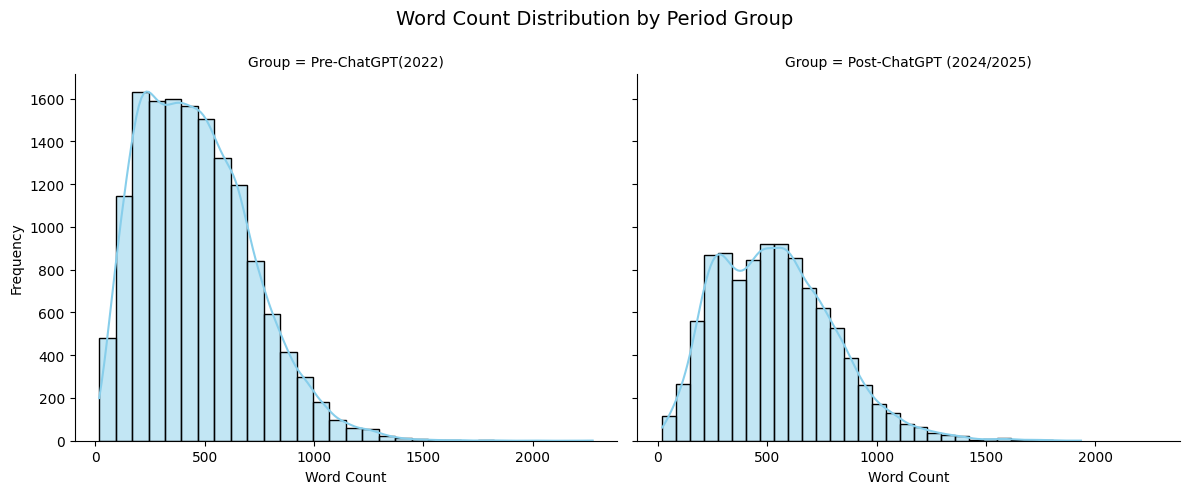

Plot saved to 'plot_outputs/word_count_distribution_by_period_group.png'


In [3]:
# Create output folder
output_plots_dir = "plot_outputs"
os.makedirs(output_plots_dir, exist_ok=True)

# Copy and preprocess
df_wc = df_all.copy() # Renaming df to _wc (word count) to avoid confusion
df_wc["summary_PostingCreated"] = pd.to_datetime(df_wc["summary_PostingCreated"], errors="coerce").dt.tz_localize(None)
df_wc["Posting_Year"] = df_wc["summary_PostingCreated"].dt.year
df_wc["Period_Group"] = df_wc["Posting_Year"].apply(
    lambda x: "2022" if x == 2022 else ("2024/2025" if x in [2024, 2025] else None)
)

# Filter out NAs from the period group and copy
df_wc_grouped = df_wc[df_wc["Period_Group"].notnull()].copy()

# Compute word counts
df_wc_grouped["word_count"] = df_wc_grouped["details_JobPositionPosting_JobPositionInformation_Purpose"].apply(
    lambda x: len(word_tokenize(x)) if pd.notnull(x) else 0
)

# Summary statistics
print(df_wc_grouped.groupby("Period_Group")["word_count"].describe())

# Faceted histogram
g = sns.FacetGrid(
    df_wc_grouped,
    col="Period_Group",
    col_order=["2022", "2024/2025"],
    height=5,
    aspect=1.2,
    sharex=True,
    sharey=True
)
g.map(sns.histplot, "word_count", bins=30, kde=True, color="skyblue")
g.set_axis_labels("Word Count", "Frequency")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Word Count Distribution by Period Group", fontsize=14)

# Save
output_path = os.path.join(output_plots_dir, "word_count_distribution_by_period_group.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Plot saved to '{output_path}'")


Creating series to use for statistical tests and some visualisations

In [4]:
# Create separate groups
group_2022 = df_wc_grouped[df_wc_grouped["Period_Group"] == "2022"]["word_count"].dropna()
group_2024_2025 = df_wc_grouped[df_wc_grouped["Period_Group"] == "2024/2025"]["word_count"].dropna()


Checks if there are any 0's.
There should not be any, so remove if there are.

In [5]:
# Check if 0's are present (there shouldn't be any)
print("Zero word counts in 2022:", (group_2022 == 0).sum())
print("Zero word counts in 2024/2025:", (group_2024_2025 == 0).sum())

# # Removes 0's if present
# group_2022 = group_2022[group_2022 > 0]
# group_2024_2025 = group_2024_2025[group_2024_2025 > 0]

Zero word counts in 2022: 0
Zero word counts in 2024/2025: 0


Creating a box plot to visualise the difference between the two periods/groups.

/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_45073/3504650325.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


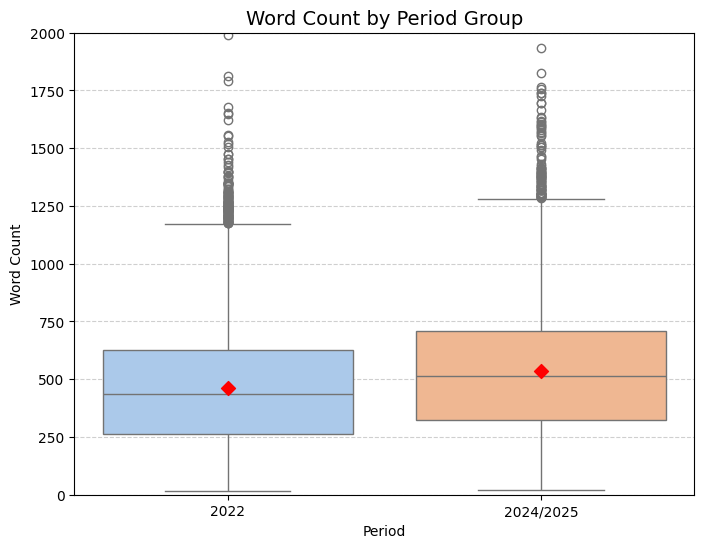

Boxplot saved to: plot_outputs/word_count_boxplot_by_period_group.png


In [6]:
# Plot setup
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_wc_grouped,
    x='Period_Group',
    y='word_count',
    order=["2022", "2024/2025"],
    palette='pastel'
)

# Add gridlines for readability
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Overlay mean values as red diamonds
means = df_wc_grouped.groupby("Period_Group")["word_count"].mean()
for i, period in enumerate(["2022", "2024/2025"]):
    plt.scatter(i, means[period], color='red', zorder=10, marker='D', s=50)

# Axis and title
plt.title("Word Count by Period Group", fontsize=14)
plt.xlabel("Period")
plt.ylabel("Word Count")
plt.ylim(0, 2000)

# Save and show
output_dir = "plot_outputs"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "word_count_boxplot_by_period_group.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Boxplot saved to: {output_path}")


### Q-Q Plots

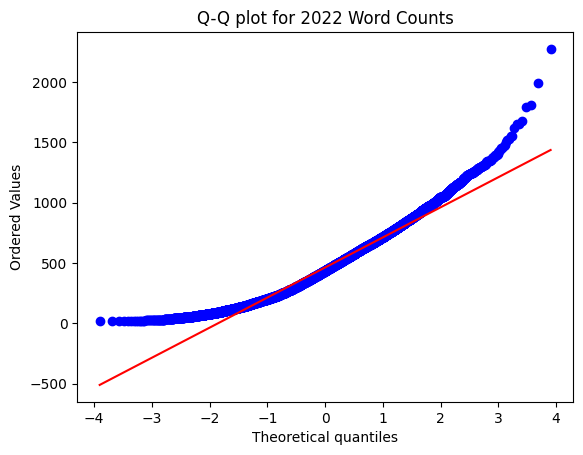

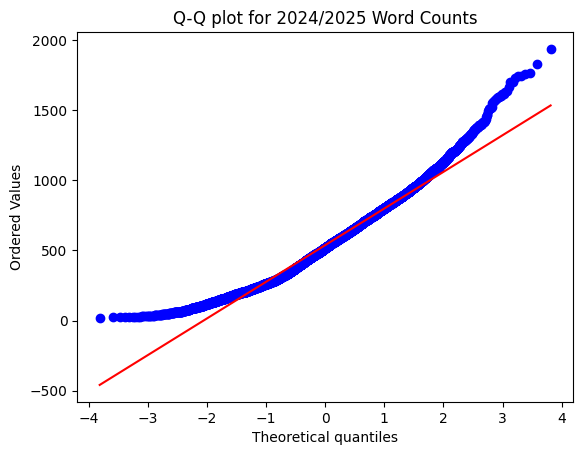

In [7]:
# For 2022
stats.probplot(group_2022, dist="norm", plot=plt)
plt.title("Q-Q plot for 2022 Word Counts")
plt.show()

# For 2024/2025
stats.probplot(group_2024_2025, dist="norm", plot=plt)
plt.title("Q-Q plot for 2024/2025 Word Counts")
plt.show()

Q-Q plot with *log-transformed* word counts

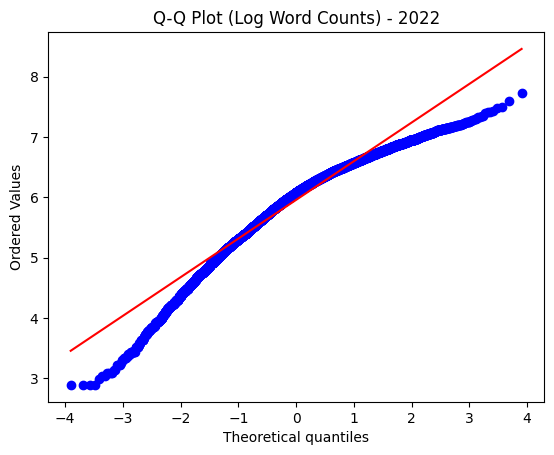

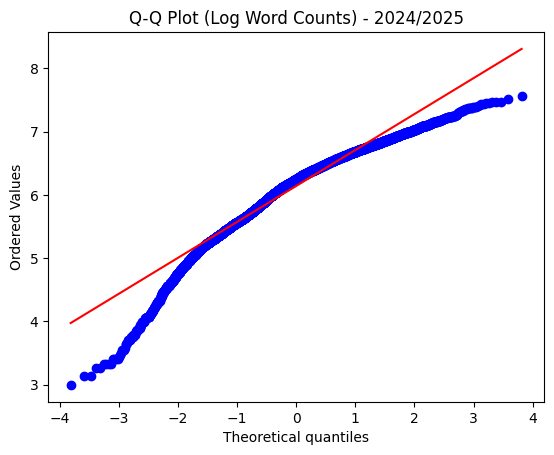

In [8]:
# For 2022
stats.probplot(np.log(group_2022), dist="norm", plot=plt)
plt.title("Q-Q Plot (Log Word Counts) - 2022")
plt.show()

# For 2024/2025
stats.probplot(np.log(group_2024_2025), dist="norm", plot=plt)
plt.title("Q-Q Plot (Log Word Counts) - 2024/2025")
plt.show()

### Levene's Test

Using Levene's test for checking homogeneity of variance between the two groups/periods

In [9]:
# Run Levene's test
stat, p_value = levene(group_2022, group_2024_2025)

print(f"Levene's test statistic: {stat:.3f}")
print(f"Levene's test p-value: {p_value:.6f}")

Levene's test statistic: 17.101
Levene's test p-value: 0.000036


Using Levene's test, but with *log-transformed* data

In [10]:
# Run Levene's test WITH LOG
stat, p_value = levene(np.log(group_2022), np.log(group_2024_2025))

print(f"Levene's test statistic: {stat:.3f}")
print(f"Levene's test p-value: {p_value:.6f}")

Levene's test statistic: 132.417
Levene's test p-value: 0.000000


### Welsch's T-test

Using Welsch's T-test for comparing groups

In [11]:
# Welsch's T-test
statistic, p_value = ttest_ind(group_2022, group_2024_2025, equal_var=False)

print(f"Welch's t-test statistic: {statistic:.3f}")
print(f"p-value: {p_value:.6f}")

Welch's t-test statistic: -21.733
p-value: 0.000000


Running Welsch's T-test, but on log-transformed data

In [12]:
# Welsch's T-test with log transformation
statistic, p_value = ttest_ind(np.log(group_2022), np.log(group_2024_2025), equal_var=False)

print(f"Welch's t-test statistic: {statistic:.3f}")
print(f"p-value: {p_value:.6f}")

Welch's t-test statistic: -23.022
p-value: 0.000000


### Cohen's D (Effect Size)

I use Cohen's D to determine the effect size

In [13]:
# Calculating means
mean_2022 = group_2022.mean()
mean_2024_2025 = group_2024_2025.mean()

# Getting standard deviations
std_2022 = group_2022.std()
std_2024_2025 = group_2024_2025.std()

# Getting sample sizes
n_2022 = len(group_2022)
n_2024_2025 = len(group_2024_2025)

# Getting the pooled standard deviation
pooled_std = np.sqrt(((n_2022 - 1) * std_2022**2 + (n_2024_2025 - 1) * std_2024_2025**2) / (n_2022 + n_2024_2025 - 2))

# Calculating Cohen's d
cohen_d = (mean_2022 - mean_2024_2025) / pooled_std

print(f"Cohen's d: {cohen_d:.3f}")

Cohen's d: -0.284


Finding Cohen's D, but with *log-transformed* data

In [14]:
# Calculating means
mean_2022 = np.log(group_2022).mean()
mean_2024_2025 = np.log(group_2024_2025).mean()

# Getting standard deviations
std_2022 = np.log(group_2022).std()
std_2024_2025 = np.log(group_2024_2025).std()

# Getting sample sizes
n_2022 = len(np.log(group_2022))
n_2024_2025 = len(np.log(group_2024_2025))

# Getting the pooled standard deviation
pooled_std = np.sqrt(((n_2022 - 1) * std_2022**2 + (n_2024_2025 - 1) * std_2024_2025**2) / (n_2022 + n_2024_2025 - 2))

# Calculating Cohen's d
cohen_d = (mean_2022 - mean_2024_2025) / pooled_std

print(f"Cohen's d: {cohen_d:.3f}")

Cohen's d: -0.292


### Robustness Check

I run a Mann-Whitney U test as a robustness check

In [15]:
# Running Mann-Whitney U test
stat, p = mannwhitneyu(group_2022, group_2024_2025, alternative='two-sided')
print(f"Mann-Whitney U p-value: {p:.6f}")

Mann-Whitney U p-value: 0.000000


Running the Mann-Whitney U with *log-transformed* values

In [16]:
# Running Mann-Whitney U test with log-transformed data
stat, p = mannwhitneyu(np.log(group_2022), np.log(group_2024_2025), alternative='two-sided')
print(f"Mann-Whitney U p-value: {p:.6f}")

Mann-Whitney U p-value: 0.000000


Since the sample sizes were on the larger side, I make a subset of the dataset and run Welch's T-test again.

In [17]:
# Random subsample (1000 per group)
sampled_2022 = df_wc_grouped[df_wc_grouped["Period_Group"] == "2022"].sample(n=1000, random_state=42)
sampled_2024_2025 = df_wc_grouped[df_wc_grouped["Period_Group"] == "2024/2025"].sample(n=1000, random_state=42)
df_wc_sampled = pd.concat([sampled_2022, sampled_2024_2025])

# Re-run Welch's t-test
group_22 = df_wc_sampled[df_wc_sampled["Period_Group"] == "2022"]["word_count"]
group_24 = df_wc_sampled[df_wc_sampled["Period_Group"] == "2024/2025"]["word_count"]
print("Welch's t-test (sampled):", ttest_ind(group_22, group_24, equal_var=False).pvalue)


Welch's t-test (sampled): 2.5497819576926636e-07
